## 2.1 Parallel LLM workflow
* building an LLM framework that judges and gives feedback for an input essay based on `Clarity of thought`, `Depth of Analysis`, `language`
* each function gives a feedback and marks out of 10
* each function then sends there results to `final evaluation` that summarizes all the feedback adn averages all the marks

In [6]:
 #libraries
from langgraph.graph import StateGraph, START, END
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
import operator

In [2]:
load_dotenv()

True

In [3]:
model=ChatGoogleGenerativeAI(
    model='gemini-3.1-flash-lite'
)

In [4]:
class schema(BaseModel):
    feedback: str = Field(description='detailed feedback for the essay')
    score: int = Field(description='score out of 10', ge=0, le=10)

In [5]:
structured_model=model.with_structured_output(schema)

In [13]:
class flow(TypedDict):
    essay: str
    lang_fb: str
    analysis_fb: str
    clarity_fb: str
    overall_fb:  str
    scores: Annotated[list[int],operator.add]
    avg_score: float


In [19]:
def eval_lang(state: flow):
    prompt=f"evaluate the language quality of the following essay and provide a short feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'lang_fb': output.feedback, 'scores': [output.score]}

In [20]:
def eval_clarity(state: flow):
    prompt=f"evaluate the clarity of thought of the following essay and provide a short feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'clarity_fb': output.feedback, 'scores': [output.score]}

In [21]:
def eval_analysis(state: flow):
    prompt=f"evaluate the depth of analysis of the following essay and provide a short feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'analysis_fb': output.feedback, 'scores': [output.score]}

In [14]:
def final_eval(state: flow):
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["lang_fb"]} \n depth of analysis feedback - {state["analysis_fb"]} \n clarity of thought feedback - {state["clarity_fb"]}'
    overall_feedback = model.invoke(prompt).content

    avg_score = sum(state['scores'])/len(state['scores'])

    return {'overall_fb': overall_feedback, 'avg_score': avg_score}

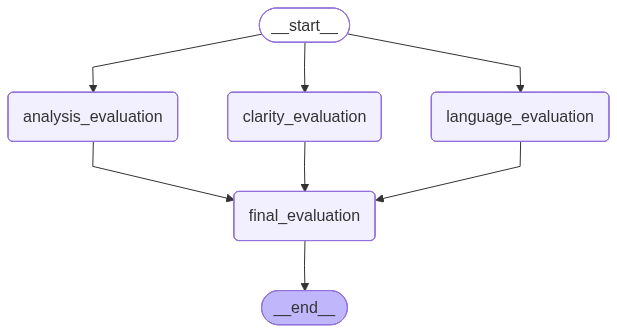

In [22]:
graph=StateGraph(flow)

#nodes
graph.add_node('language_evaluation',eval_lang)
graph.add_node('analysis_evaluation',eval_analysis)
graph.add_node('clarity_evaluation',eval_clarity)
graph.add_node('final_evaluation', final_eval)

#edges
graph.add_edge(START,'language_evaluation')
graph.add_edge(START,'analysis_evaluation')
graph.add_edge(START,'clarity_evaluation')

graph.add_edge('language_evaluation','final_evaluation')
graph.add_edge('analysis_evaluation','final_evaluation')
graph.add_edge('clarity_evaluation','final_evaluation')

graph.add_edge('final_evaluation', END)

workflow=graph.compile()

workflow

In [17]:
essay='''
    AI has grown quickly from science fiction to a daily reality. Years ago, it was just basic computer programs. Now, it is everywhere. We see AI in our phones, giving us navigation or movie suggestions. It has become a standard tool that helps people with simple tasks. Recently, AI has advanced even more. Programs can now create art or write essays for us. This makes life easier but also brings some uncertainty about our future. We are still learning how to live with these new technologies. It is a big change that impacts everyone in their normal lives.
'''

In [28]:
essay2='''
    AI is getting really big lately. Before it was just in movies but now it is in phones. AI can do things like talk to you or make a picture for you. It changed a lot of stuff. Some people are happy because it helps work and some people are scared because maybe it takes jobs away. I think it is weird how it is everywhere now. You can just ask it stuff and it answers. It is confusing because we did not have it before. Everything is super different now and it keeps changing fast every day.
'''

In [29]:
initial_state={'essay': essay2}
final_state=workflow.invoke(initial_state)

In [31]:
final_state['overall_fb']

[{'type': 'text',
  'text': 'Here is a summarized version of the feedback:\n\n**Summary of Feedback**\n\nWhile your essay successfully identifies the basic premise of AI’s growth and its dual impact on society, it currently lacks the academic rigor required for a formal analysis. To improve your work, focus on the following areas:\n\n*   **Elevate Your Language:** Move away from a casual, conversational tone. Replace vague descriptors (e.g., "big," "stuff," "weird") with precise, academic vocabulary and improve sentence variety to avoid repetition.\n*   **Deepen Your Analysis:** Shift from surface-level observations toward a nuanced exploration of causes and societal implications. Avoid merely stating that AI is "helpful" or "scary" by supporting your points with specific examples and a stronger, evidence-based thesis.\n*   **Structure and Flow:** Enhance the coherence of your writing by incorporating effective transition words and adopting a more formal, organized structure. \n\nIn sh